sentiment analysis positive & negative

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=10000)

In [3]:
print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

Training samples: 25000
Testing samples: 25000


In [4]:
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=200)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=200)

In [5]:
model = keras.Sequential([
    layers.Embedding(input_dim=10000, output_dim=128, input_length=200),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')   # Binary Output
])

c:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [6]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [7]:
history = model.fit(x_train, y_train,
                    epochs=5,
                    batch_size=64,
                    validation_split=0.2)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.7722 - loss: 0.4407 - val_accuracy: 0.8630 - val_loss: 0.3177
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.9743 - loss: 0.0759 - val_accuracy: 0.8442 - val_loss: 0.4842
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.9976 - loss: 0.0082 - val_accuracy: 0.8450 - val_loss: 0.8274
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.9980 - loss: 0.0051 - val_accuracy: 0.8306 - val_loss: 0.9382
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.9929 - loss: 0.0225 - val_accuracy: 0.8342 - val_loss: 0.7365


In [8]:
loss, acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8298 - loss: 0.7746
Test Accuracy: 0.829800009727478


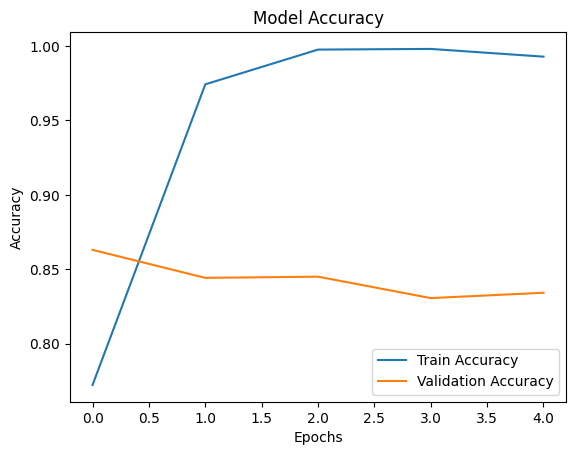

In [9]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.show()

In [10]:
word_index = keras.datasets.imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}
def decode_review(text):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in text])
for i in range(5):
    print("Review", i+1)
    print(decode_review(x_test[i]))
    print("-"*50)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Review 1
? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? please give this one a miss br br ? ? and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite ? so all you madison fans give this a miss
--------------------------------------------------
Review 2
psychological ? it's very interesting that robert altman directed this considering the style and structure of his other films still the trademark altman audio style is evident here and there i think what really makes this film work is the brilliant performance by sandy dennis it's defin

In [11]:
pred = model.predict(x_test[:5])

for i in range(5):
    print("Review", i+1, "Prediction:",
          "Positive" if pred[i] > 0.5 else "Negative")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
Review 1 Prediction: Negative
Review 2 Prediction: Positive
Review 3 Prediction: Negative
Review 4 Prediction: Positive
Review 5 Prediction: Positive
